<a href="https://colab.research.google.com/github/MLFundamentals/making-ai/blob/main/notebooks/MNIST_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9498 - loss: 0.1637 - val_accuracy: 0.9817 - val_loss: 0.0647
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9838 - loss: 0.0522 - val_accuracy: 0.9842 - val_loss: 0.0543
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9884 - loss: 0.0357 - val_accuracy: 0.9853 - val_loss: 0.0515
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9909 - loss: 0.0273 - val_accuracy: 0.9877 - val_loss: 0.0433
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9938 - loss: 0.0191 - val_accuracy: 0.9881 - val_loss: 0.0433
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9939 - loss: 0.0175 - val_accuracy: 0.9902 - val_loss: 0.0411
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9962 - loss: 0.0114 - val_accuracy: 0.9888 - val_loss: 0.0460
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9966 - loss: 0.0098 - 

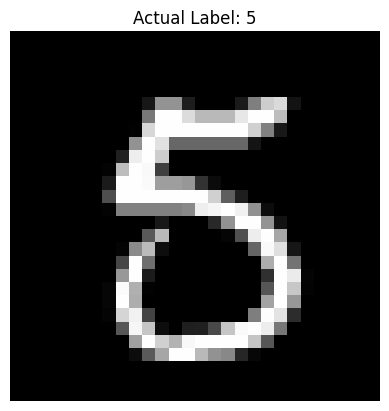


➜ 모델이 예측한 레이블: 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

# MNIST 데이터셋 불러오기
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# CNN 입력에 맞게 shape 변경: (28, 28, 1) / 정규화
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# 레이블 데이터를 원-핫 인코딩으로 변환
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# CNN 모델 구성
model = Sequential([
    Input(shape=(28, 28, 1)),                            # 흑백 이미지이므로 채널 수 1
    Conv2D(32, kernel_size=(3, 3), activation='relu'),   # 필터 32개, 3x3 크기
    MaxPooling2D(pool_size=(2, 2)),                      # 2x2 풀링
    Conv2D(64, kernel_size=(3, 3), activation='relu'),   # 필터 64개
    MaxPooling2D(pool_size=(2, 2)),                      # 또 한 번 풀링
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# 모델 컴파일
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 학습
model.fit(x_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# 모델 평가
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f'\n모델 정확도: {test_acc * 100:.2f} %\n')

# 테스트 이미지 판독 예제
print('\n▶ 임의의 이미지 판독 테스트\n')
sample_index = np.random.randint(0, x_test.shape[0])
sample_image = x_test[sample_index]

plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f'Actual Label: {y_test[sample_index]}')
plt.axis('off')
plt.show()

# 입력 형식 맞추기: (1, 28, 28, 1)
sample_input = sample_image.reshape(1, 28, 28, 1).astype('float32')
prediction = model.predict(sample_input, verbose=0)
predicted_label = np.argmax(prediction)
print('\n➜ 모델이 예측한 레이블:', predicted_label)